# Customer Churn Prediction
## 1. Loading the Data

In [29]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Fousia\Downloads\ml project\archive\telecom_customer_churn.csv")
print(df.head())
print(df.shape)


  Customer ID  Gender  Age Married  Number of Dependents          City  \
0  0002-ORFBO  Female   37     Yes                     0  Frazier Park   
1  0003-MKNFE    Male   46      No                     0      Glendale   
2  0004-TLHLJ    Male   50      No                     0    Costa Mesa   
3  0011-IGKFF    Male   78     Yes                     0      Martinez   
4  0013-EXCHZ  Female   75     Yes                     0     Camarillo   

   Zip Code   Latitude   Longitude  Number of Referrals  ...   Payment Method  \
0     93225  34.827662 -118.999073                    2  ...      Credit Card   
1     91206  34.162515 -118.203869                    0  ...      Credit Card   
2     92627  33.645672 -117.922613                    0  ...  Bank Withdrawal   
3     94553  38.014457 -122.115432                    1  ...  Bank Withdrawal   
4     93010  34.227846 -119.079903                    3  ...      Credit Card   

  Monthly Charge Total Charges  Total Refunds Total Extra Data Charg

In [30]:
print(df.info())
print(df.columns.tolist())
print(df['Customer Status'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   str    
 1   Gender                             7043 non-null   str    
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   str    
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   str    
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null   str    
 12  Pho

In [31]:
print(df.isnull().sum())

Customer ID                             0
Gender                                  0
Age                                     0
Married                                 0
Number of Dependents                    0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges     682
Multiple Lines                        682
Internet Service                        0
Internet Type                        1526
Avg Monthly GB Download              1526
Online Security                      1526
Online Backup                        1526
Device Protection Plan               1526
Premium Tech Support                 1526
Streaming TV                         1526
Streaming Movies                  

## 2. Data CleaningHandling structurally missing values(eg."NO Internet Service"customer correctly have blank internet-related fields)

In [32]:
internet_cols = ['Internet Type','Avg Monthly GB Download','Online Security','Online Backup','Device Protection Plan','Premium Tech Support','Streaming TV','Streaming Movies','Streaming Music']
for col in internet_cols:
    df[col] = df[col].fillna("No Internet Service")
df['Multiple Lines'] = df['Multiple Lines'].fillna("No Phone Service")
df['Avg Monthly Long Distance Charges'] = df['Avg Monthly Long Distance Charges'].fillna(0)
df['Offer'] = df['Offer'].fillna("No Offer")
df['Churn Category'] = df['Churn Category'].fillna("did not churn")
df['Churn Reason'] = df['Churn Reason'].fillna("did not churn")


In [33]:
print(df.isnull().sum())


Customer ID                             0
Gender                                  0
Age                                     0
Married                                 0
Number of Dependents                    0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Number of Referrals                     0
Tenure in Months                        0
Offer                                   0
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                        0
Internet Type                           0
Avg Monthly GB Download                 0
Online Security                         0
Online Backup                           0
Device Protection Plan                  0
Premium Tech Support                    0
Streaming TV                            0
Streaming Movies                  

## 3. Expolatory Data AnalysisComparing churned vs stayed customers across key features.

In [34]:
df_model = df[df['Customer Status'] != 'Joined'].copy()

In [35]:
print(df_model['Customer Status'].value_counts())

Customer Status
Stayed     4720
Churned    1869
Name: count, dtype: int64


In [36]:
print(df_model.groupby('Customer Status')['Tenure in Months'].mean())

Customer Status
Churned    17.979133
Stayed     41.041525
Name: Tenure in Months, dtype: float64


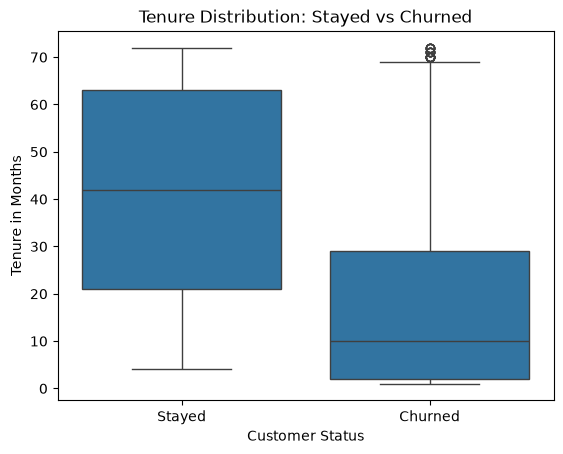

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(data=df_model, x='Customer Status', y='Tenure in Months')
plt.title('Tenure Distribution: Stayed vs Churned')
plt.show()

In [38]:
numeric_cols = ['Tenure in Months','Monthly Charge','Total Revenue','Age','Number of Referrals']
print(df_model.groupby('Customer Status')[numeric_cols].mean())

                 Tenure in Months  Monthly Charge  Total Revenue        Age  \
Customer Status                                                               
Churned                 17.979133       73.347592    1971.353569  49.735688   
Stayed                  41.041525       61.737415    3735.676297  45.582415   

                 Number of Referrals  
Customer Status                       
Churned                     0.521134  
Stayed                      2.614831  


## 4. Feature Encoding and Train?Test Split

In [39]:
df_model['Churn_Flag'] = df_model['Customer Status'].map({'Stayed' : 0, 'Churned': 1})

In [40]:
yes_no_cols = ['Phone Service','Paperless Billing','Married']
for col in yes_no_cols:
    df_model[col] = df_model[col].map({'Yes':1,'No':0})

In [41]:
categorical_cols = df_model.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('Customer Status')
categorical_cols.remove('Customer ID')
categorical_cols.remove('City')
df_model = df_model.drop(columns=['City'])
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

C:\Users\Fousia\AppData\Local\Temp\ipykernel_3320\1792593918.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_model.select_dtypes(include='object').columns.tolist()


In [42]:
from sklearn.model_selection import train_test_split
leak_cols = [col for col in df_model.columns if col.startswith('Churn Category') or col.startswith('Churn Reason')]
X = df_model.drop(columns=['Customer Status','Churn_Flag','Customer ID'] + leak_cols)
y = df_model['Churn_Flag']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [43]:
print(X_train.shape)
print(X_test.shape)


(5271, 97)
(1318, 97)


In [44]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## 5.Baseline Model: Logististc Regression

In [45]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [46]:
from sklearn.metrics import confusion_matrix, classification_report
y_pred = model.predict(X_test_scaled)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))


[[846  89]
 [108 275]]
              precision    recall  f1-score   support

           0       0.89      0.90      0.90       935
           1       0.76      0.72      0.74       383

    accuracy                           0.85      1318
   macro avg       0.82      0.81      0.82      1318
weighted avg       0.85      0.85      0.85      1318



##6. Random Forest and Comparison


In [47]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [48]:
from sklearn.metrics import classification_report
rf_pred = rf_model.predict(X_test)
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.86      0.96      0.91       935
           1       0.87      0.63      0.73       383

    accuracy                           0.86      1318
   macro avg       0.87      0.79      0.82      1318
weighted avg       0.87      0.86      0.86      1318



## 7.Feature Importance

In [49]:
importances = rf_model.feature_importances_
print(importances)

[3.90124755e-02 1.03118019e-02 2.45479319e-02 3.50700960e-02
 3.53738201e-02 3.41489642e-02 5.13912954e-02 9.99124624e-02
 1.86806929e-03 3.68983948e-02 1.05773167e-02 5.16252795e-02
 9.08313118e-02 5.84337321e-03 7.32765408e-03 5.93167052e-02
 8.30882896e-02 7.21353833e-03 2.37561203e-03 4.50725465e-03
 2.50503183e-03 3.47591409e-03 1.25919455e-02 1.54556809e-03
 7.79573203e-03 6.88467028e-03 9.44130559e-03 2.01641220e-02
 4.25306002e-03 2.16414741e-03 2.18345082e-03 2.03064838e-03
 1.29059164e-03 1.41271562e-03 1.72978413e-03 1.65213774e-03
 2.08604479e-03 1.86549338e-03 1.71360398e-03 1.94315041e-03
 1.97861900e-03 1.56928559e-03 1.99153985e-03 1.98751794e-03
 1.55893682e-03 2.07145868e-03 2.04035149e-03 2.25623795e-03
 1.92046638e-03 1.98946402e-03 1.49485013e-03 1.83639398e-03
 1.99740350e-03 1.76273838e-03 1.93463862e-03 1.77620275e-03
 1.90680548e-03 0.00000000e+00 9.33467976e-04 8.74092124e-04
 2.57650843e-04 6.85096793e-04 1.20997363e-03 1.47199846e-03
 1.24582631e-03 8.788359

In [50]:
import pandas as pd
feature_importance_df = pd.DataFrame({
    'Feature' : X_train.columns,
    'Importance' : rf_model.feature_importances_
}).sort_values('Importance',ascending=False)
print(feature_importance_df.head(10))

                              Feature  Importance
7                    Tenure in Months    0.099912
12                      Total Charges    0.090831
16                      Total Revenue    0.083088
15        Total Long Distance Charges    0.059317
11                     Monthly Charge    0.051625
6                 Number of Referrals    0.051391
94                  Contract_Two Year    0.042419
0                                 Age    0.039012
9   Avg Monthly Long Distance Charges    0.036898
4                            Latitude    0.035374


## 8. Hyperparameter Tuning

In [51]:
rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)
rf_tuned.fit(X_train,y_train)
rf_tuned_pred = rf_tuned.predict(X_test)
print(classification_report(y_test,rf_tuned_pred))

              precision    recall  f1-score   support

           0       0.93      0.86      0.89       935
           1       0.71      0.85      0.77       383

    accuracy                           0.86      1318
   macro avg       0.82      0.85      0.83      1318
weighted avg       0.87      0.86      0.86      1318



## Summary of Findings

**Key churn drivers identified:**
- Tenure is the strongest predictor — churned customers average ~18 months vs. ~41 months for retained customers
- Customers with fewer referrals churn far more often (0.52 avg vs 2.61 avg) — referrals appear to signal loyalty/satisfaction
- Longer contracts (especially 2-year) strongly reduce churn likelihood
- Higher monthly charges correlate with higher churn risk

**Model performance:**
- Logistic Regression (baseline): 85% accuracy, 0.72 recall on churned customers
- Random Forest (default): 86% accuracy, but only 0.63 recall on churned customers
- Random Forest (tuned, class-weighted): 86% accuracy, 0.85 recall on churned customers — final chosen model

**Why the tuned model was selected:** In churn prediction, missing a real churner (false negative) is typically costlier than a false alarm, since a missed churner is a lost customer. The tuned model was optimized to prioritize recall accordingly.

**Business recommendation:** Target retention efforts at low-tenure, low-referral customers on month-to-month contracts — this segment shows the highest churn risk based on feature importance analysis.

## 9.Saving the Model for Deployment

In [52]:
import joblib 
joblib.dump(rf_tuned,'churn_model.pkl')
joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']

In [53]:
print(list(X_train.columns))

['Age', 'Married', 'Number of Dependents', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals', 'Tenure in Months', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Paperless Billing', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Gender_Male', 'Offer_Offer A', 'Offer_Offer B', 'Offer_Offer C', 'Offer_Offer D', 'Offer_Offer E', 'Multiple Lines_No Phone Service', 'Multiple Lines_Yes', 'Internet Service_Yes', 'Internet Type_DSL', 'Internet Type_Fiber Optic', 'Internet Type_No Internet Service', 'Avg Monthly GB Download_3.0', 'Avg Monthly GB Download_4.0', 'Avg Monthly GB Download_5.0', 'Avg Monthly GB Download_6.0', 'Avg Monthly GB Download_7.0', 'Avg Monthly GB Download_8.0', 'Avg Monthly GB Download_9.0', 'Avg Monthly GB Download_10.0', 'Avg Monthly GB Download_11.0', 'Avg Monthly GB Download_12.0', 'Avg Monthly GB Download_13.0', 'Avg Monthly GB Download_14.0', 'Avg Monthly GB Download_15.0

In [54]:
import json
sample_customer = X_test.iloc[0].to_dict()
print(json.dumps(sample_customer))

{"Age": 56, "Married": 0, "Number of Dependents": 0, "Zip Code": 95828, "Latitude": 38.486938, "Longitude": -121.395805, "Number of Referrals": 0, "Tenure in Months": 2, "Phone Service": 1, "Avg Monthly Long Distance Charges": 6.47, "Paperless Billing": 1, "Monthly Charge": 45.15, "Total Charges": 98.5, "Total Refunds": 0.0, "Total Extra Data Charges": 0, "Total Long Distance Charges": 12.94, "Total Revenue": 111.44, "Gender_Male": true, "Offer_Offer A": false, "Offer_Offer B": false, "Offer_Offer C": false, "Offer_Offer D": false, "Offer_Offer E": true, "Multiple Lines_No Phone Service": false, "Multiple Lines_Yes": false, "Internet Service_Yes": true, "Internet Type_DSL": true, "Internet Type_Fiber Optic": false, "Internet Type_No Internet Service": false, "Avg Monthly GB Download_3.0": false, "Avg Monthly GB Download_4.0": false, "Avg Monthly GB Download_5.0": false, "Avg Monthly GB Download_6.0": false, "Avg Monthly GB Download_7.0": false, "Avg Monthly GB Download_8.0": false, "Av

In [ ]:
import requests
response = requests.post('http://127.0.0.1:5000/predict',json =sample_customer)


<bound method Response.json of <Response [200]>>


In [57]:
print(response.json())

{'churn_prediction': 1, 'churn_probability': 0.876}


In [58]:
print(y_test.iloc[0])

1
